=== CONTRIB START ===

## Section 11 - Hyperparameter Tuning Summary

Section 3.8 of the brief requires every tuning run recorded in a dedicated table. This
section builds that table from the three run logs written during training. Nothing is
re-trained. Every number is read from files the four training notebooks produced.

The integrity checks are the evidence that the ten models are comparable. One dataset
checksum across all rows proves every model saw the same splits. One scoring module
produced every metric, so macro-F1 means the same thing in all rows.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import sys, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR    = Path("/content/drive/MyDrive/cse440_project")
SPLIT_DIR   = DATA_DIR / "splits"
RESULTS_DIR = DATA_DIR / "results"
FIG_DIR     = DATA_DIR / "figures" / "final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DATA_DIR))
import utils.evaluation as ev

label_meta  = ev.load_label_meta(SPLIT_DIR)
CLASSES     = label_meta["classes"]
SUPERCLASS  = label_meta["superclass"]
NUM_CLASSES = label_meta["num_classes"]

log_files = sorted(RESULTS_DIR.rglob("runs_*.csv"))
print(f"run logs found: {len(log_files)}")
for f in log_files:
    print(f"  {f.relative_to(DATA_DIR)}")

runs = pd.concat([pd.read_csv(f) for f in log_files], ignore_index=True)
runs["kind"] = runs.notes.astype(str).str.split().str[0]

print(f"\nrows: {len(runs)} | columns: {len(runs.columns)}")
print(f"contributors: {sorted(runs.owner.unique())}")

Mounted at /content/drive
run logs found: 3
  results/fabiha/runs_fabiha.csv
  results/hasib/runs_hasib.csv
  results/zawad/runs_zawad.csv

rows: 36 | columns: 28
contributors: ['fabiha', 'hasib', 'zawad']


### Integrity checks

Thirty required runs, matching the brief exactly, plus six ablations. Ten models. One
distinct checksum. One schema across three separately written files.

In [2]:
required = runs[runs.kind == "required"]
ablation = runs[runs.kind == "ablation"]

print("run counts by contributor")
print(pd.crosstab(runs.owner, runs.kind, margins=True).to_string())

print(f"\nrequired runs : {len(required)}  (brief requires 30)")
print(f"ablation runs : {len(ablation)}")
print(f"models covered: {runs.model.nunique()}")
print(f"checksums     : {runs.dataset_checksum.nunique()} distinct "
      f"-> {runs.dataset_checksum.unique().tolist()}")
print(f"schema        : {len(ev.RUN_COLUMNS)} columns in the shared contract")

assert len(required) == 30, f"expected 30 required runs, found {len(required)}"
assert runs.dataset_checksum.nunique() == 1, "contributors trained on different data"
assert runs.model.nunique() == 10, f"expected 10 models, found {runs.model.nunique()}"
print("\nintegrity: PASS")

run counts by contributor
kind    ablation  required  All
owner                          
fabiha         2         6    8
hasib          3        15   18
zawad          1         9   10
All            6        30   36

required runs : 30  (brief requires 30)
ablation runs : 6
models covered: 10
checksums     : 1 distinct -> [13885266476465583340]
schema        : 26 columns in the shared contract

integrity: PASS


### The tuning table

Thirty-six runs grouped by tier: 12 classical, 20 recurrent, 4 transformer.

Classical rows show `NaN` in the recurrent columns because a Logistic Regression has no
units, dropout, embedding or epoch count. Those rows are kept rather than dropped, since
nine of the thirty required runs sit in them.

In [3]:
TUNE_COLS = ["owner", "tier", "kind", "model", "config", "embedding",
             "units", "dropout", "trainable_emb", "learning_rate",
             "epochs_run", "best_epoch", "val_accuracy", "val_macro_f1",
             "train_time_s"]

tune = runs[TUNE_COLS].sort_values(
    ["tier", "model", "config"],
    key=lambda s: s.map({"classical": 0, "recurrent": 1, "transformer": 2}) if s.name == "tier" else s
).reset_index(drop=True)

pd.set_option("display.width", 200)
for tier in ["classical", "recurrent", "transformer"]:
    block = tune[tune.tier == tier]
    print("=" * 130)
    print(f"{tier.upper()}  ({len(block)} runs)")
    print("=" * 130)
    print(block.drop(columns=["tier"]).to_string(index=False))
    print()

tune.to_csv(RESULTS_DIR / "tuning_table_all.csv", index=False)
print(f"saved tuning_table_all.csv  ({len(tune)} rows)")

CLASSICAL  (12 runs)
owner     kind              model      config   embedding  units  dropout trainable_emb  learning_rate  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
hasib required LogisticRegression       LR-C1 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7385        0.7241         10.38
hasib required LogisticRegression       LR-C2 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7477        0.7377         12.11
hasib ablation LogisticRegression LR-C2-light tfidf_light    NaN      NaN           NaN            NaN         NaN         NaN        0.7312        0.7218         15.94
hasib required LogisticRegression       LR-C3 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7446        0.7353         11.03
hasib required      MultinomialNB       NB-C1 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        

### Runs that reached the epoch cap

A run that used its full epoch budget never triggered early stopping, which means
validation performance was still improving when training stopped. Those configurations
are undertrained and their scores are a floor rather than a ceiling.

The recurrent cap was 30 epochs, agreed by the group after the first two notebooks were
found to disagree at 20 and 30. BERT was given 3 or 4 epochs on the standard reasoning
that fine-tuning overfits quickly.

This is reported rather than corrected. Raising either budget now would mean retraining
every model in that tier to keep the comparison fair.

In [4]:
MAX_RECURRENT_EPOCHS = 30

seq = runs[runs.tier == "recurrent"].copy()
tra = runs[runs.tier == "transformer"].copy()

capped = seq[seq.epochs_run >= MAX_RECURRENT_EPOCHS]
print(f"recurrent runs that used the full {MAX_RECURRENT_EPOCHS}-epoch budget: "
      f"{len(capped)} of {len(seq)}\n")
print(capped[["owner", "model", "config", "embedding", "trainable_emb",
              "epochs_run", "best_epoch", "val_macro_f1"]].to_string(index=False))

frozen = capped[~capped.trainable_emb.astype(bool)]
print(f"\nof these, {len(frozen)} have a frozen embedding and "
      f"{len(capped) - len(frozen)} do not")

tra_capped = tra[tra.best_epoch == tra.epochs_run]
print(f"\ntransformer runs peaking at their final epoch: {len(tra_capped)} of {len(tra)}")
print(tra_capped[["model", "config", "epochs_run", "best_epoch",
                  "val_macro_f1"]].to_string(index=False))
print("\nevery run listed here is undertrained; its score is a floor")

recurrent runs that used the full 30-epoch budget: 9 of 20

 owner       model    config embedding trainable_emb  epochs_run  best_epoch  val_macro_f1
fabiha        LSTM ABL-clean     glove           0.0        30.0        30.0      0.621928
fabiha        LSTM ABL-light     glove           0.0        30.0        30.0      0.588909
fabiha        LSTM        S1     glove           0.0        30.0        30.0      0.612044
fabiha        LSTM        S2  word2vec           0.0        30.0        28.0      0.609424
fabiha        LSTM        S3  word2vec           1.0        30.0        28.0      0.712222
fabiha     Bi-LSTM        S1     glove           0.0        30.0        28.0      0.637763
 hasib BiSimpleRNN        S3  word2vec           1.0        30.0        30.0      0.464000
 zawad         GRU        S1     glove           0.0        30.0        29.0      0.628668
 zawad         GRU        S2  word2vec           0.0        30.0        29.0      0.613096

of these, 7 have a frozen emb

## Section 12 - Consolidated Results and Comparison

Section 3.9 requires every model evaluated on the test set using its best configuration,
compared through tables and figures.

Best configuration means highest validation macro-F1. With 20 classes and an imbalanced
test split, macro-F1 weights every class equally, so a model cannot score well by
handling only the largest groups. The test set was touched once per model, after
selection was complete.

The six ablation runs are excluded here. They vary a preprocessing or sequence-length
setting rather than a hyperparameter, so they are not competing configurations.

In [5]:
final = runs[runs.kind == "required"].dropna(subset=["test_accuracy"]).copy()
final = final.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
final.insert(0, "rank", range(1, len(final) + 1))

TABLE_COLS = ["rank", "model", "config", "tier", "embedding",
              "test_accuracy", "test_macro_f1", "test_weighted_f1",
              "val_macro_f1", "train_time_s", "owner"]

assert len(final) == 10, f"expected 10 models, got {len(final)}"

print("=" * 118)
print("TEST SET - best configuration per model")
print("=" * 118)
print(final[TABLE_COLS].to_string(index=False))

final[TABLE_COLS].to_csv(RESULTS_DIR / "final_comparison.csv", index=False)

best  = final.iloc[0]
worst = final.iloc[-1]
print(f"\nbest-performing  : {best.model} ({best.config})   "
      f"macro-F1 {best.test_macro_f1:.4f}")
print(f"worst-performing : {worst.model} ({worst.config})   "
      f"macro-F1 {worst.test_macro_f1:.4f}")
print(f"spread           : {best.test_macro_f1 - worst.test_macro_f1:.4f}")

TEST SET - best configuration per model
 rank              model config        tier   embedding  test_accuracy  test_macro_f1  test_weighted_f1  val_macro_f1  train_time_s  owner
    1          BERT-Base     B3 transformer   wordpiece       0.734508       0.722483          0.735043      0.775260        602.40  zawad
    2 LogisticRegression  LR-C2   classical tfidf_clean       0.698200       0.685200          0.696000      0.737700         12.11  hasib
    3      MultinomialNB  NB-C2   classical tfidf_clean       0.703800       0.684300          0.696900      0.734800          0.02  hasib
    4            Bi-LSTM     S3   recurrent    word2vec       0.676673       0.662737          0.675130      0.728305        104.60 fabiha
    5               LSTM     S3   recurrent    word2vec       0.671991       0.655076          0.668418      0.712222         78.90 fabiha
    6             Bi-GRU     S3   recurrent    word2vec       0.640870       0.630409          0.641252      0.706949         

### Accuracy and macro-F1 across all ten models

The two metrics track each other closely, which is expected because the corpus is close
to balanced at roughly 600 to 1,000 documents per class. Where they separate, macro-F1
is the lower of the two, meaning the model is weaker on the smaller classes than its
accuracy suggests.

The ordering is not by tier. The two strongest classical models sit above all six
recurrent models, and only the transformer beats them.

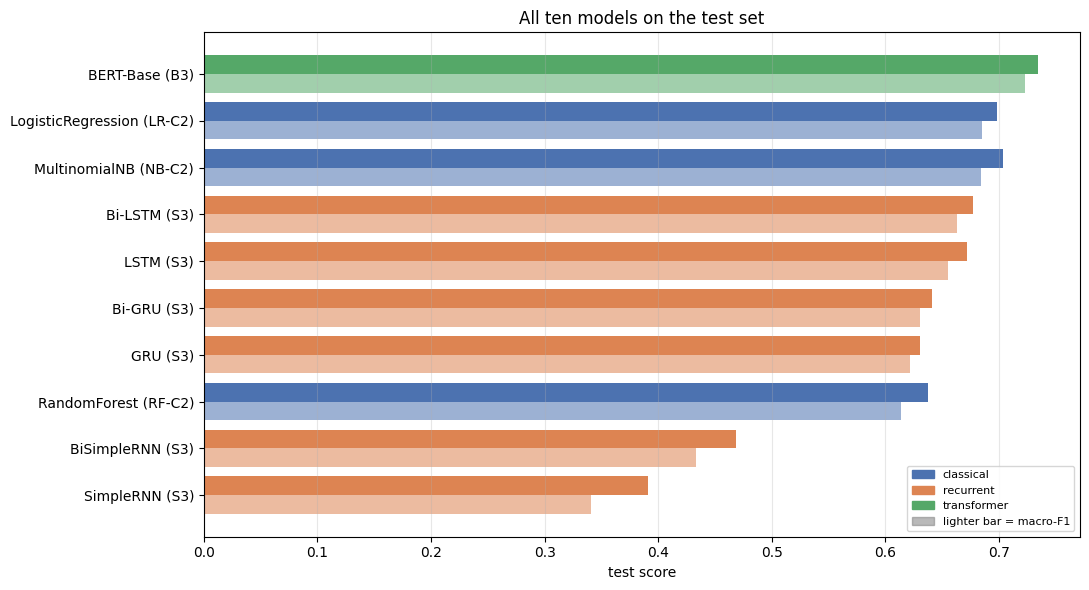

In [6]:
TIER_COLOUR = {"classical": "#4c72b0", "recurrent": "#dd8452", "transformer": "#55a868"}

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(final))
ax.barh(y - 0.2, final.test_accuracy, 0.4, label="accuracy",
        color=[TIER_COLOUR[t] for t in final.tier])
ax.barh(y + 0.2, final.test_macro_f1, 0.4, label="macro-F1",
        color=[TIER_COLOUR[t] for t in final.tier], alpha=0.55)
ax.set_yticks(y)
ax.set_yticklabels([f"{m} ({c})" for m, c in zip(final.model, final.config)])
ax.invert_yaxis()
ax.set_xlabel("test score")
ax.set_title("All ten models on the test set")
ax.grid(axis="x", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in TIER_COLOUR.values()]
ax.legend(handles + [plt.Rectangle((0, 0), 1, 1, color="grey", alpha=0.55)],
          list(TIER_COLOUR) + ["lighter bar = macro-F1"], fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Accuracy against training cost

The horizontal axis is log-scaled because training times span five orders of magnitude,
from 0.02 seconds for Naive Bayes to 602 seconds for BERT.

This figure carries the argument a ranked table hides. The best model is far from the
cheapest, and the gap in accuracy is much smaller than the gap in compute.

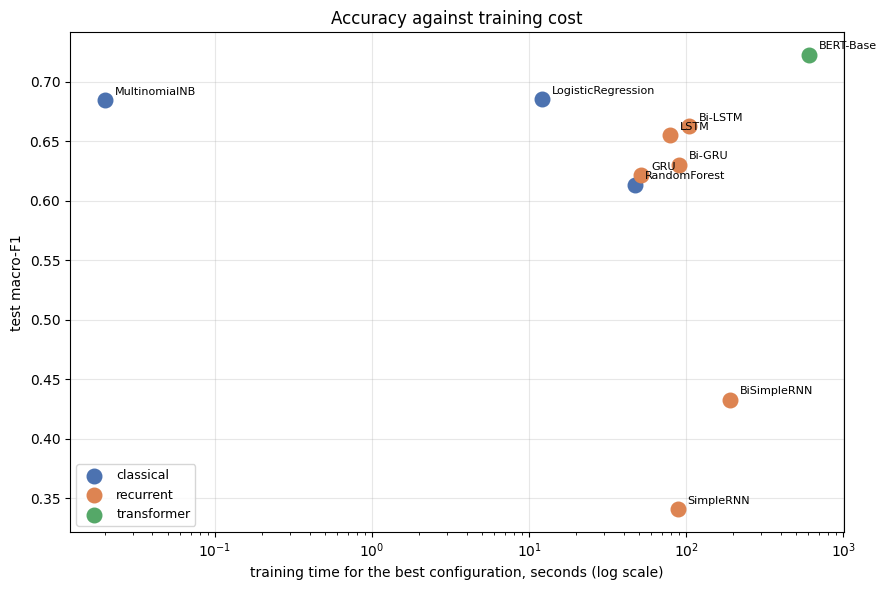

BERT-Base      0.7225 macro-F1 in   602.40s
LogisticRegression 0.6852 macro-F1 in    12.11s

gain from the transformer : +0.0373 macro-F1
cost multiplier           : 50x


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
for tier, grp in final.groupby("tier"):
    ax.scatter(grp.train_time_s, grp.test_macro_f1, s=110,
               color=TIER_COLOUR[tier], label=tier, zorder=3)
for _, r in final.iterrows():
    ax.annotate(r.model, (r.train_time_s, r.test_macro_f1),
                textcoords="offset points", xytext=(7, 4), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("training time for the best configuration, seconds (log scale)")
ax.set_ylabel("test macro-F1")
ax.set_title("Accuracy against training cost")
ax.grid(alpha=0.3, zorder=0)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

top_class = final[final.tier == "classical"].iloc[0]
top_all   = final.iloc[0]
print(f"{top_all.model:14s} {top_all.test_macro_f1:.4f} macro-F1 in {top_all.train_time_s:>8.2f}s")
print(f"{top_class.model:14s} {top_class.test_macro_f1:.4f} macro-F1 in {top_class.train_time_s:>8.2f}s")
print(f"\ngain from the transformer : {top_all.test_macro_f1 - top_class.test_macro_f1:+.4f} macro-F1")
print(f"cost multiplier           : {top_all.train_time_s / max(top_class.train_time_s, 0.01):,.0f}x")

## Section 13 - Confusion Matrix Heatmaps

Every matrix is rebuilt from the JSON reports the four training notebooks saved. No model
is reloaded and nothing is re-predicted.

Matrices are row-normalised. A bright off-diagonal cell means a class is losing a large
share of its own documents to another class, rather than simply being a large class.

Eleven reports exist on Drive. The sequence-length ablation is held separately so it
cannot be mistaken for an eleventh model.

In [8]:
report_files = sorted(RESULTS_DIR.rglob("test_*.json"))
print(f"saved test reports found: {len(report_files)}")

CM, CM_ABL = {}, {}
for p in report_files:
    with open(p) as fh:
        payload = json.load(fh)
    cm = np.array(payload["confusion_matrix"], dtype=float)
    entry = {
        "cm": cm,
        "cm_norm": cm / np.maximum(cm.sum(axis=1, keepdims=True), 1),
        "accuracy": payload["accuracy"],
        "macro_f1": payload["macro_f1"],
        "family": payload.get("family_split"),
        "file": p.relative_to(DATA_DIR),
    }
    target = CM_ABL if "ABL" in payload["model"].upper() else CM
    target[payload["model"]] = entry

print(f"required models: {len(CM)} | ablation runs held separately: {len(CM_ABL)}\n")
for name, d in sorted(CM.items(), key=lambda kv: -kv[1]["macro_f1"]):
    print(f"  {name:28s} macro-F1 {d['macro_f1']:.4f}   {d['file']}")

assert len(CM) == 10, f"expected 10 required reports, found {len(CM)}"

saved test reports found: 11
required models: 10 | ablation runs held separately: 1

  BERT-Base B3                 macro-F1 0.7225   results/zawad/bert/reports/test_BERT-Base_B3.json
  LogisticRegression (LR-C2)   macro-F1 0.6852   results/hasib/test_LogisticRegression_LR-C2.json
  MultinomialNB (NB-C2)        macro-F1 0.6843   results/hasib/test_MultinomialNB_NB-C2.json
  Bi-LSTM (S3)                 macro-F1 0.6627   results/fabiha/test_Bi-LSTM_S3.json
  LSTM (S3)                    macro-F1 0.6551   results/fabiha/test_LSTM_S3.json
  Bi-GRU S3                    macro-F1 0.6304   results/zawad/gru/reports/test_Bi-GRU_S3.json
  GRU S3                       macro-F1 0.6214   results/zawad/gru/reports/test_GRU_S3.json
  RandomForest (RF-C2)         macro-F1 0.6134   results/hasib/test_RandomForest_RF-C2.json
  BiSimpleRNN (S3)             macro-F1 0.4328   results/hasib/test_BiSimpleRNN_S3.json
  SimpleRNN (S3)               macro-F1 0.3405   results/hasib/test_SimpleRNN_S3.json


### Best and worst model, full 20 by 20

The two ends of the ranking at full size. The diagonal is the signal. What matters is
whether the off-diagonal mass forms blocks or spreads evenly, because blocks mean the
errors follow the semantics of the label set rather than noise.

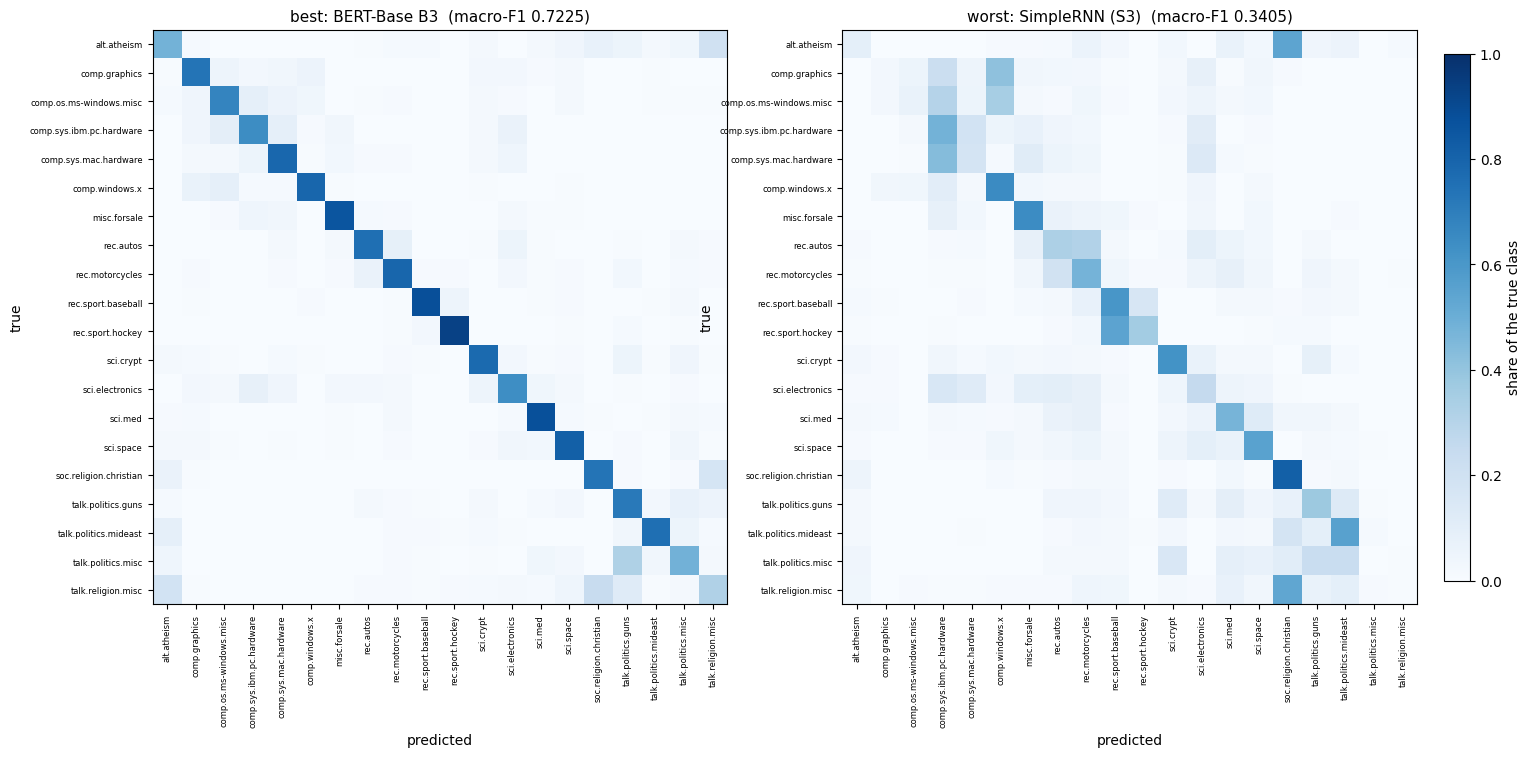

In [9]:
def plot_cm(ax, cm_norm, title):
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=90, fontsize=6)
    ax.set_yticklabels(CLASSES, fontsize=6)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title, fontsize=11)
    return im

ranked = sorted(CM.items(), key=lambda kv: -kv[1]["macro_f1"])
best_name, best_cm   = ranked[0]
worst_name, worst_cm = ranked[-1]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
im = plot_cm(axes[0], best_cm["cm_norm"],
             f"best: {best_name}  (macro-F1 {best_cm['macro_f1']:.4f})")
plot_cm(axes[1], worst_cm["cm_norm"],
        f"worst: {worst_name}  (macro-F1 {worst_cm['macro_f1']:.4f})")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="share of the true class")
fig.savefig(FIG_DIR / "cm_best_vs_worst.png", dpi=150, bbox_inches="tight")
plt.show()

### The confusable class families, side by side

Ten full matrices printed together are unreadable, so this is the focused view: the best
model from each of the three tiers, on the two blocks that carry most of the difficulty.

The five `comp.*` classes share almost all their vocabulary. The three religion-adjacent
classes argue about the same subject from different positions. If contextual embeddings
help anywhere, these are the classes where a bag of static word vectors should struggle
most.

comparing best of each tier: ['BERT-Base B3', 'Bi-LSTM (S3)', 'LogisticRegression (LR-C2)']



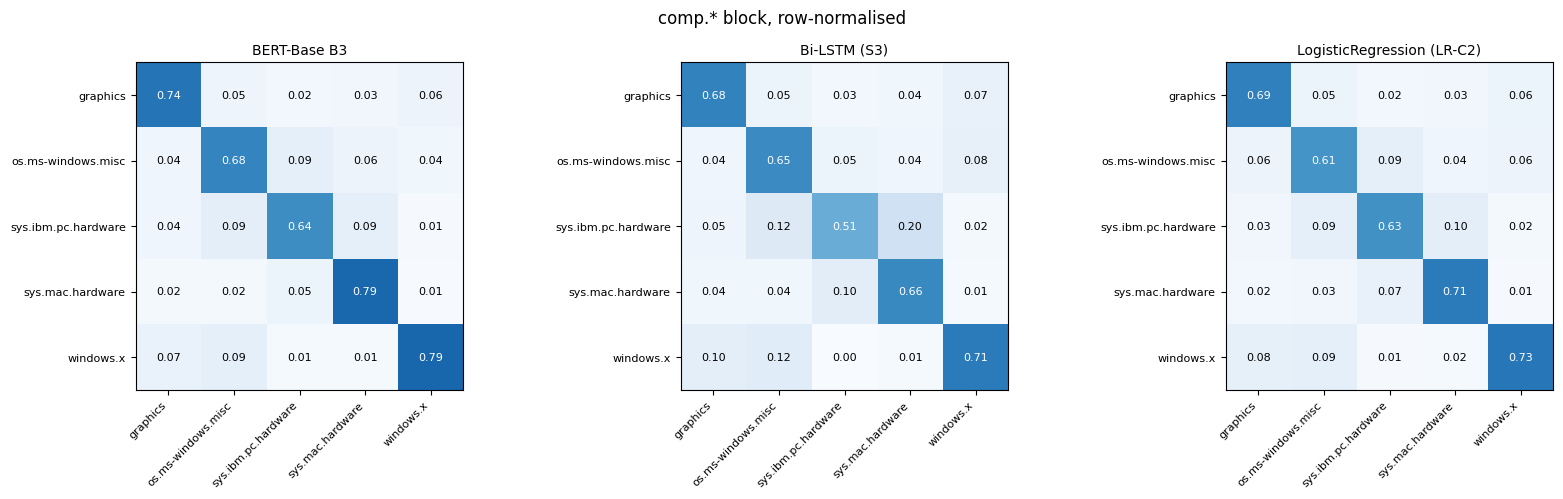

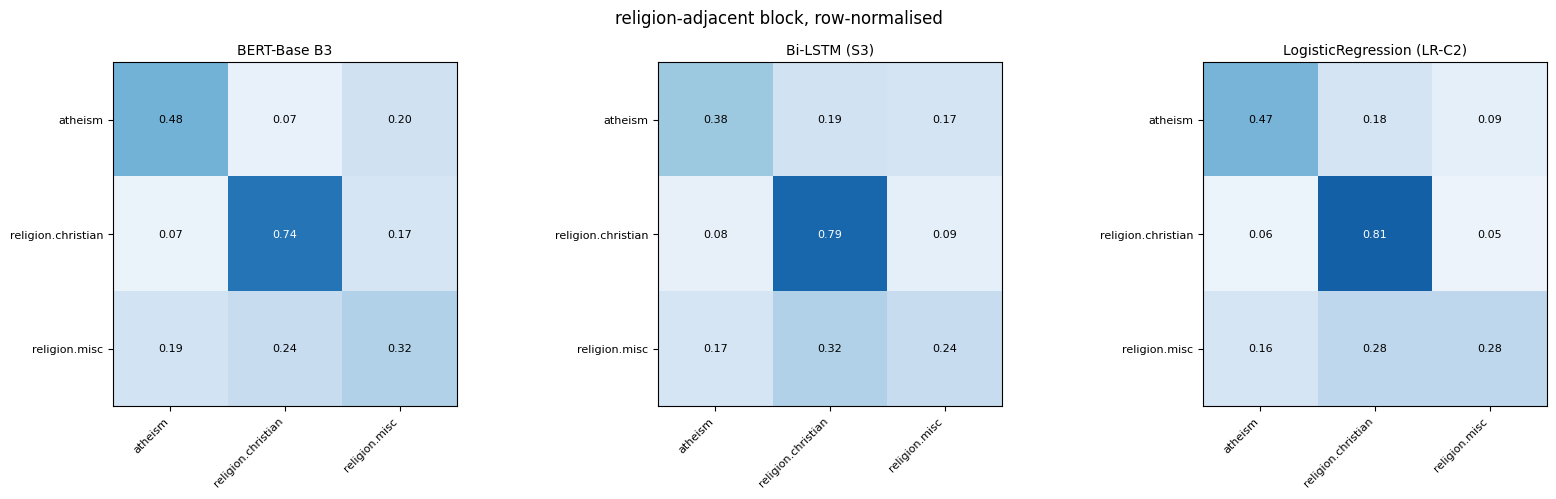

diagonal (share of each class correctly kept) inside each block

comp.*
  BERT-Base B3             mean 0.727   min 0.641
  Bi-LSTM (S3)             mean 0.641   min 0.505
  LogisticRegression (LR-C2) mean 0.673   min 0.615

religion
  BERT-Base B3             mean 0.511   min 0.317
  Bi-LSTM (S3)             mean 0.469   min 0.239
  LogisticRegression (LR-C2) mean 0.519   min 0.276



In [10]:
COMP_BLOCK = [c for c in CLASSES if c.startswith("comp.")]
RELIGION_BLOCK = ["alt.atheism", "soc.religion.christian", "talk.religion.misc"]

def block_view(cm_norm, names):
    idx = [CLASSES.index(n) for n in names]
    return cm_norm[np.ix_(idx, idx)]

TIER_MEMBERS = {
    "transformer": ["BERT"],
    "recurrent":   ["LSTM", "GRU", "SimpleRNN"],
    "classical":   ["LogisticRegression", "MultinomialNB", "RandomForest"],
}
compare = []
for members in TIER_MEMBERS.values():
    cands = [n for n, _ in ranked if any(m in n for m in members)]
    if cands:
        compare.append(cands[0])
print(f"comparing best of each tier: {compare}\n")

for block_name, block in [("comp.*", COMP_BLOCK), ("religion-adjacent", RELIGION_BLOCK)]:
    fig, axes = plt.subplots(1, len(compare), figsize=(5.5 * len(compare), 5))
    axes = np.atleast_1d(axes)
    for ax, name in zip(axes, compare):
        sub = block_view(CM[name]["cm_norm"], block)
        im = ax.imshow(sub, cmap="Blues", vmin=0, vmax=1)
        short = [b.replace("comp.", "").replace("talk.", "").replace("soc.", "")
                  .replace("alt.", "") for b in block]
        ax.set_xticks(range(len(block))); ax.set_yticks(range(len(block)))
        ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(short, fontsize=8)
        for i in range(len(block)):
            for j in range(len(block)):
                ax.text(j, i, f"{sub[i, j]:.2f}", ha="center", va="center",
                        fontsize=8, color="white" if sub[i, j] > 0.5 else "black")
        ax.set_title(name, fontsize=10)
    fig.suptitle(f"{block_name} block, row-normalised", fontsize=12)
    fig.tight_layout()
    stem = block_name.replace(".*", "").replace("-", "_")
    fig.savefig(FIG_DIR / f"cm_block_{stem}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("diagonal (share of each class correctly kept) inside each block\n")
for block_name, block in [("comp.*", COMP_BLOCK), ("religion", RELIGION_BLOCK)]:
    print(block_name)
    for name in compare:
        d = np.diag(block_view(CM[name]["cm_norm"], block))
        print(f"  {name:24s} mean {d.mean():.3f}   min {d.min():.3f}")
    print()

### Where the errors fall

The 20 labels group into 7 families by prefix, so a misclassification is one of two
kinds. Confusing two `comp.sys.*` groups is a fine-grained failure between genuinely
similar topics. Confusing one with `talk.politics.guns` is a failure at topic
identification.

If wrong answers were spread randomly across the other 19 labels, roughly 15% would land
in the same family by chance. Every model runs far above that, so the errors follow
meaning rather than noise.

                     model  macro_f1  errors  within_family  cross_family  within_%
              BERT-Base B3    0.7225    1928            770          1158      39.9
LogisticRegression (LR-C2)    0.6852    2192            798          1394      36.4
     MultinomialNB (NB-C2)    0.6843    2151            802          1349      37.3
              Bi-LSTM (S3)    0.6627    2348            956          1392      40.7
                 LSTM (S3)    0.6551    2382            944          1438      39.6
                 Bi-GRU S3    0.6304    2608            999          1609      38.3
                    GRU S3    0.6214    2684           1016          1668      37.9
      RandomForest (RF-C2)    0.6134    2634            908          1726      34.5
          BiSimpleRNN (S3)    0.4328    3861           1809          2052      46.9
            SimpleRNN (S3)    0.3405    4421           1950          2471      44.1

chance rate for within-family errors: about 15%


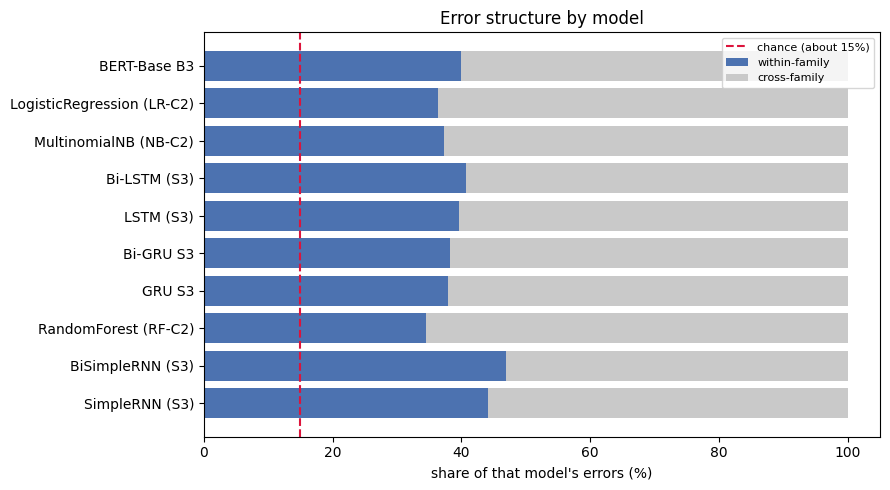

In [11]:
fam_rows = []
for name, d in ranked:
    f = d["family"]
    if not f:
        continue
    fam_rows.append({
        "model": name,
        "macro_f1": round(d["macro_f1"], 4),
        "errors": f["n_errors"],
        "within_family": f["within_family"],
        "cross_family": f["cross_family"],
        "within_%": round(100 * f["within_share"], 1),
    })
fam = pd.DataFrame(fam_rows)
print(fam.to_string(index=False))
print(f"\nchance rate for within-family errors: about 15%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fam.model, fam["within_%"], color="#4c72b0", label="within-family")
ax.barh(fam.model, 100 - fam["within_%"], left=fam["within_%"],
        color="#c9c9c9", label="cross-family")
ax.axvline(15, color="crimson", ls="--", lw=1.5, label="chance (about 15%)")
ax.invert_yaxis()
ax.set_xlabel("share of that model's errors (%)")
ax.set_title("Error structure by model")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "family_error_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 14 - Discussion

Section 3.9 asks which configurations outperformed others and why, grounded in the EDA
findings and the theoretical properties of the methods. Three evidence tables follow, then
the written analysis.

### Evidence 1: the embedding contrast across all six recurrent models

S1 and S2 differ only in the embedding matrix. Units, dropout and the frozen flag are
identical, so any difference is attributable to the embedding source alone. This is the
cleanest controlled comparison in the project, repeated across six architectures.

In [12]:
emb = runs[(runs.tier == "recurrent") & (runs.config.isin(["S1", "S2"]))]
emb_pivot = emb.pivot_table(index="model", columns="embedding", values="val_macro_f1")
emb_pivot["delta (w2v - glove)"] = (emb_pivot["word2vec"] - emb_pivot["glove"]).round(4)
emb_pivot["winner"] = np.where(emb_pivot["delta (w2v - glove)"] > 0, "word2vec", "glove")

order = ["SimpleRNN", "BiSimpleRNN", "GRU", "Bi-GRU", "LSTM", "Bi-LSTM"]
emb_pivot = emb_pivot.reindex([m for m in order if m in emb_pivot.index])
print(emb_pivot.round(4).to_string())

gated = emb_pivot[~emb_pivot.index.str.contains("SimpleRNN")]
ungated = emb_pivot[emb_pivot.index.str.contains("SimpleRNN")]
print(f"\nungated models preferring word2vec : {(ungated.winner == 'word2vec').sum()} of {len(ungated)}")
print(f"gated models preferring glove      : {(gated.winner == 'glove').sum()} of {len(gated)}")
print("\ncoverage: word2vec 99.995% of the vocabulary, glove 87.32%")

embedding     glove  word2vec  delta (w2v - glove)    winner
model                                                       
SimpleRNN    0.2853    0.3351               0.0498  word2vec
BiSimpleRNN  0.3880    0.4114               0.0234  word2vec
GRU          0.6287    0.6131              -0.0156     glove
Bi-GRU       0.6270    0.6104              -0.0166     glove
LSTM         0.6120    0.6094              -0.0026     glove
Bi-LSTM      0.6378    0.6130              -0.0247     glove

ungated models preferring word2vec : 2 of 2
gated models preferring glove      : 4 of 4

coverage: word2vec 99.995% of the vocabulary, glove 87.32%


### Evidence 2: architecture against the length distribution

The recurrent models are ordered by how much gating they have. Mahir's EDA showed the
length distribution is heavily right-skewed, with the mean far above the median, so the
distance information must travel inside the hidden state is large.

In [13]:
arch_order = ["SimpleRNN", "BiSimpleRNN", "GRU", "Bi-GRU", "LSTM", "Bi-LSTM"]
arch = final[final.model.isin(arch_order)].set_index("model")
arch = arch.reindex([m for m in arch_order if m in arch.index])
print(arch[["config", "test_accuracy", "test_macro_f1", "train_time_s"]].to_string())

if "SimpleRNN" in arch.index and "GRU" in arch.index:
    print(f"\ngating (SimpleRNN to GRU)      : "
          f"{arch.loc['GRU','test_macro_f1'] - arch.loc['SimpleRNN','test_macro_f1']:+.4f}")
for uni, bi in [("SimpleRNN", "BiSimpleRNN"), ("GRU", "Bi-GRU"), ("LSTM", "Bi-LSTM")]:
    if uni in arch.index and bi in arch.index:
        print(f"bidirectional ({uni:<11s})   : "
              f"{arch.loc[bi,'test_macro_f1'] - arch.loc[uni,'test_macro_f1']:+.4f}")

            config  test_accuracy  test_macro_f1  train_time_s
model                                                         
SimpleRNN       S3       0.391200       0.340500         88.31
BiSimpleRNN     S3       0.468300       0.432800        190.03
GRU             S3       0.630405       0.621351         51.70
Bi-GRU          S3       0.640870       0.630409         89.90
LSTM            S3       0.671991       0.655076         78.90
Bi-LSTM         S3       0.676673       0.662737        104.60

gating (SimpleRNN to GRU)      : +0.2809
bidirectional (SimpleRNN  )   : +0.0923
bidirectional (GRU        )   : +0.0091
bidirectional (LSTM       )   : +0.0077


### Evidence 3: the ablation studies

Six ablations beyond the thirty required runs. Three on the classical tier and two on an
LSTM testing the preprocessing strategy, and one on BERT testing sequence length.

The two preprocessing ablations test the same question through different mechanisms. For
TF-IDF the cost of keeping stopwords is feature slots under a 20,000-term cap. For a
sequence model it is timesteps inside a 250-token window.

In [14]:
abl_view = ablation[["owner", "tier", "model", "config", "embedding",
                     "val_macro_f1", "test_macro_f1", "train_time_s", "notes"]]
print(abl_view.to_string(index=False))

clean_light = runs[(runs.tier == "classical")].pivot_table(
    index="model", columns="embedding", values="val_macro_f1", aggfunc="max")
if {"tfidf_clean", "tfidf_light"}.issubset(clean_light.columns):
    clean_light["delta (clean - light)"] = (clean_light["tfidf_clean"]
                                            - clean_light["tfidf_light"]).round(4)
    print("\nclassical preprocessing ablation, validation macro-F1")
    print(clean_light.round(4).to_string())

 owner        tier              model      config   embedding  val_macro_f1  test_macro_f1  train_time_s                                                    notes
fabiha   recurrent               LSTM   ABL-clean       glove      0.621928            NaN         79.50       ablation preprocessing: text_clean (full strategy)
fabiha   recurrent               LSTM   ABL-light       glove      0.588909            NaN         73.30                       ablation preprocessing: text_light
 hasib   classical LogisticRegression LR-C2-light tfidf_light      0.721800            NaN         15.94 ablation preprocessing: text_light instead of text_clean
 hasib   classical      MultinomialNB NB-C2-light tfidf_light      0.717900            NaN          0.03 ablation preprocessing: text_light instead of text_clean
 hasib   classical       RandomForest RF-C2-light tfidf_light      0.651800            NaN         82.74 ablation preprocessing: text_light instead of text_clean
 zawad transformer          

### Analysis

**The best model is BERT at 0.7225 test macro-F1 and the worst is SimpleRNN at 0.3405.**
The spread of 0.3820 is the largest single fact in the results, and both ends are
explained by the same property of the data.

Mahir's EDA showed the length distribution is heavily right-skewed, because quoted reply
chains drag the tail. In a SimpleRNN, information from an early token reaches the
classifier only by surviving one matrix multiplication per timestep. Over documents of
this length that path is unreliable. Adding gates fixes it: the jump from SimpleRNN to
GRU is +0.2809 macro-F1, the largest architectural gain anywhere in the project, and it
comes from letting part of the hidden state pass forward unchanged.

BERT removes the distance problem rather than managing it. Every token attends to every
other token directly, so nothing has to survive a chain of updates, and it arrives
pretrained rather than learning English and the task at once.

**The transformer advantage is not uniform.** Inside the `comp.*` block BERT keeps 0.727
of each class on average, against Logistic Regression at 0.673 and Bi-LSTM at 0.641.
Inside the religion block the ordering changes: Logistic Regression reaches 0.519,
slightly ahead of BERT at 0.511.

The two blocks are hard for different reasons. The `comp.*` classes are separated by what
a word means in context, so "windows" or "driver" needs the surrounding sentence to
resolve, which is what attention supplies. The religion classes are separated by stance
on a shared subject. All three discuss the same vocabulary, and the signal is which
specific terms appear at all rather than what they mean in context. That is what TF-IDF
measures directly, so a bag of words is not at a disadvantage there.

**The embedding result contradicts what the coverage numbers suggested.** Phase 0
reported 99.995% vocabulary coverage for Word2Vec against 87.32% for GloVe, and the
natural prediction was that full coverage would win. The measured result splits by
architecture. Both ungated models preferred Word2Vec, by +0.0498 and +0.0234 macro-F1.
All four gated models preferred GloVe, by 0.0026 to 0.0247.

Coverage and quality are different properties. GloVe was estimated from six billion
tokens of general English, so the 87.32% it covers sits well in the space. Word2Vec here
was trained on roughly 9,000 documents, so every word has a vector but each rests on very
little evidence. A model that cannot build context depends on individual token identity,
and for it a noisy vector beats a zero vector. A model that can build context exploits
the finer structure in better-estimated vectors, and loses less from a missing token
because the surrounding words supply the meaning.

**Preprocessing mattered less than the cap it interacts with.** The classical ablation
found the cleaned strategy ahead on all three models, by +0.0159, +0.0169 and +0.0075
validation macro-F1. The LSTM ablation found a larger gap, 0.6219 against 0.5889, a
+0.0330 advantage for cleaning. The mechanisms differ. Under TF-IDF the light vocabulary
spends slots on function words and inflected variants, so a 20,000-feature cap represents
fewer topical concepts. Under a sequence model those same words consume positions in a
250-token window. Mahir measured the vocabulary side of this at 66,111 terms under light
against 54,253 under full.

**Sequence length is not the binding constraint it appeared to be.** The BERT ablation is
the clearest evidence. Cutting truncation from 24.4% of documents to 9.1%, which means
seeing 15.2% more of the corpus, changed macro-F1 by +0.0016 for 1.85 times the training
time. The small bidirectional gains point the same way from a different direction:
+0.0091 for the GRU pair and +0.0077 for the LSTM pair. If the identifying vocabulary
appeared late in documents, both reading backwards and reading further forward would help,
and neither does much. Topic signal in these posts is front-loaded.

The exception is telling. The bidirectional gain for SimpleRNN is +0.0923, ten times the
gain for the gated pairs. A model that cannot retain early tokens benefits from a second
pass that reaches them from the other end. A model that can retain them has nothing to
gain.

**Errors are semantic, not random, for every model.** Within-family errors run far above
the roughly 15% that random guessing would produce.

The share is highest for the weakest models: Bi-SimpleRNN at 46.9% and SimpleRNN at
44.1%, against BERT's 39.9%. That looks backwards until the absolute counts are read
alongside it. SimpleRNN makes 1,950 within-family errors, BERT makes 770. The weak models
pick up coarse family-level vocabulary and fail on the fine distinctions inside a family,
so they land in the right family with the wrong label. The strong models fix most of
those, and what remains is a smaller set concentrated in genuinely confusable pairs. The
share alone is misleading and the counts carry the finding.

One caveat on the metric. `alt.atheism`, `soc.religion.christian` and
`talk.religion.misc` sit in three different families under the prefix taxonomy but are
the most semantically adjacent trio in the dataset, so confusions among them count as
cross-family failures when they are not really that.

**On cost.** BERT reaches 0.7225 macro-F1 in 602 seconds. Logistic Regression reaches
0.6852 in 12 seconds, and Naive Bayes reaches 0.6843 in 0.02 seconds. The transformer
buys +0.0373 over the best classical model for roughly fifty times the training time, and
roughly thirty thousand times the time of the second-best.

Whether that is worth it depends on the application. For coarse topic routing the
classical model is the better engineering choice. What BERT buys specifically is the
`comp.*` block, and that is visible in the block matrices rather than in the headline
number.

## Section 15 - Conclusion

### Key takeaways

Ten models were trained across three families, thirty required runs plus six ablations,
all against frozen shared artifacts verified by a single dataset checksum and scored by
one shared module.

The ranking follows each architecture's capacity to carry information across a long
document. Ungated recurrence performs worst at 0.3405 macro-F1. Gating closes most of the
gap, reaching 0.6627 at best. Attention with pretraining performs best at 0.7225.

A simple classical model on TF-IDF remains competitive. Logistic Regression reaches
0.6852 and Naive Bayes 0.6843, both above every recurrent model in the project. Newsgroup
topics are strongly keyword-driven, which suits a bag-of-features representation, and this
is why the transformer's advantage is smaller than its compute cost suggests.

Three controlled comparisons produced results that contradicted the expectation drawn from
the EDA. Embedding coverage did not predict embedding usefulness. Sequence length was not
a binding constraint. And the transformer did not win everywhere, losing the religion
block to TF-IDF. All three are reported as measured.

### Limitations

The embedding dimension was fixed at 50 for both GloVe and Word2Vec. This is the smallest
GloVe set available and caps what the recurrent tier can represent for 20 classes. It was
held constant so the two sources stay dimensionally comparable, which makes the S1 against
S2 contrast clean at the cost of absolute performance.

Several configurations used their full epoch budget with validation performance still
improving, so those runs are undertrained. Most of them are frozen-embedding recurrent
runs, which converge more slowly than the trainable ones. All three BERT configurations
also peaked at their final epoch, so the transformer numbers are a floor as well.

24.4% of documents are truncated at 256 WordPiece tokens for BERT. The ablation shows the
cost is small but not zero. The two tiers also do not see the same span of document: the
recurrent models read 250 tokens of cleaned text, which covers more of the original
document than 256 subword tokens does.

The test split holds 7,262 rows rather than the standard 7,532, because Phase 0 removed
515 empty documents and 557 below a minimum character length. Results are therefore not
directly comparable to published 20 Newsgroups figures without stating this. A further
226 test documents also appear in train, which is a property of the published benchmark
and was reported rather than deleted.

Validation scores run consistently above test scores for every model. BERT is 0.7753 on
validation against 0.7225 on test. The published train and test boundary is temporal, so
test posts come from a later period than training, while validation was carved from
within training. This affects all ten models equally, so the ranking holds, but absolute
test numbers sit below what validation suggests.

TF-IDF and the embedding representations were never compared on the same model. TF-IDF
fed the classical tier and the embeddings fed the recurrent tier, so the representation
comparison is confounded with the architecture comparison.

### Future improvements

Raise the embedding dimension to 100 or 300 and re-run the recurrent tier. At 50
dimensions this is the most likely single constraint on those results.

Extend the epoch budget for the configurations that used all of theirs, so every model is
compared at convergence rather than at a fixed budget.

Run one classical model on averaged embedding vectors and one recurrent model on TF-IDF,
which would separate the representation effect from the architecture effect that is
currently confounded.

Merge the three religion-adjacent classes into one and re-measure. Logistic Regression
already matches BERT on that block, which suggests the remaining error there is a property
of a label set that separates classes people separate by stance rather than topic.

=== CONTRIB END ===